# Time Series Introduction

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

from statsmodels.tsa.seasonal import seasonal_decompose

In [41]:
path = '../../data/passengers.csv'
df = pd.read_csv(path)
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [42]:
df.columns = ['Date', 'Passengers']
df.head(1)

,Date,Passengers
0,1949-01,112


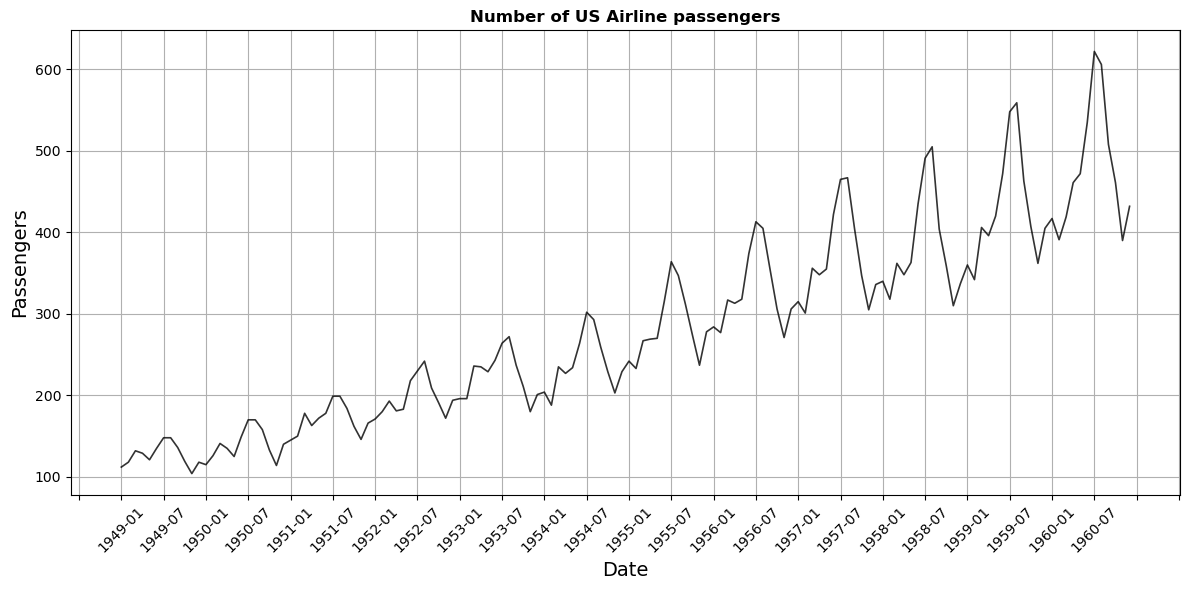

In [43]:
from matplotlib.ticker import MaxNLocator, MultipleLocator

def plot_function(df, x, y, title = "", xlabel = "Date", ylabel = "Passengers", dpi = 100):
    plt.figure(figsize = (12,6), dpi = dpi)
    plt.plot(x,y, color = "black", linewidth = 1.2, alpha = 0.8)
    plt.title(title, fontweight = 'bold')
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)

    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(30))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_function(df, x = df['Date'], y = df['Passengers'], title = "Number of US Airline passengers")

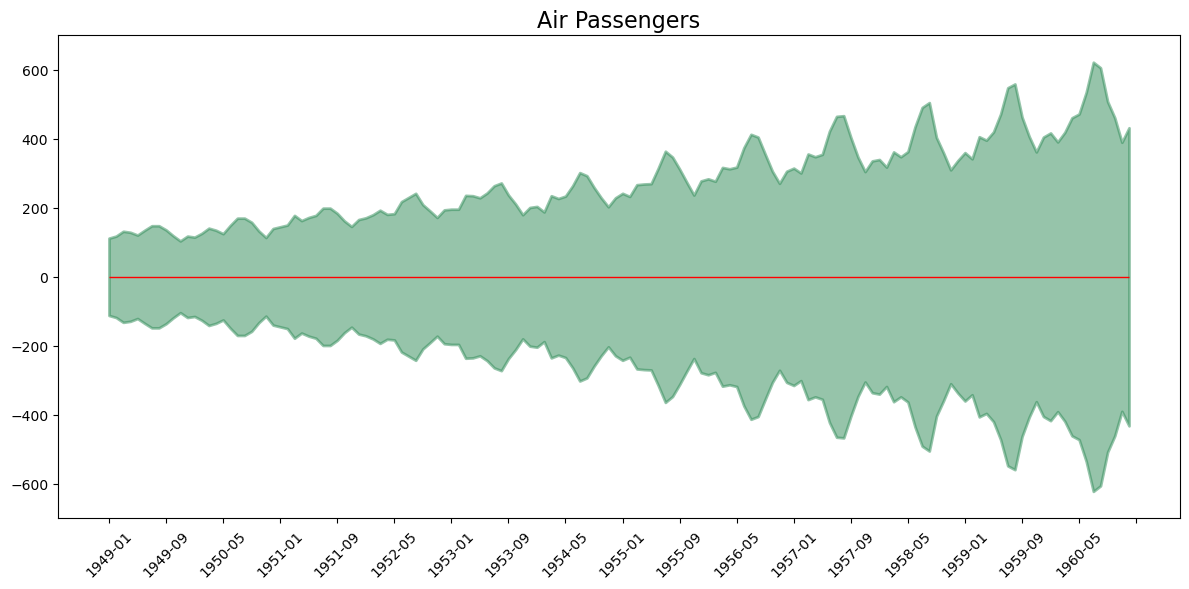

In [44]:
x = df['Date'].values
y1 = df['Passengers'].values

fig,ax = plt.subplots(1,1, figsize = (12,6), dpi = 100)
plt.fill_between(x = x, y1 = y1, y2 = - y1, alpha = 0.5, linewidth = 2, color = "seagreen")
plt.ylim(-700,700)
plt.title("Air Passengers", fontsize = 16)
plt.hlines(y=0, xmin=np.min(df['Date']), xmax=np.max(df['Date']), linewidth=1, color = 'red')

plt.xticks(rotation = 45, fontsize = 10)
ax.xaxis.set_major_locator(MaxNLocator(20))
plt.tight_layout()
plt.show()

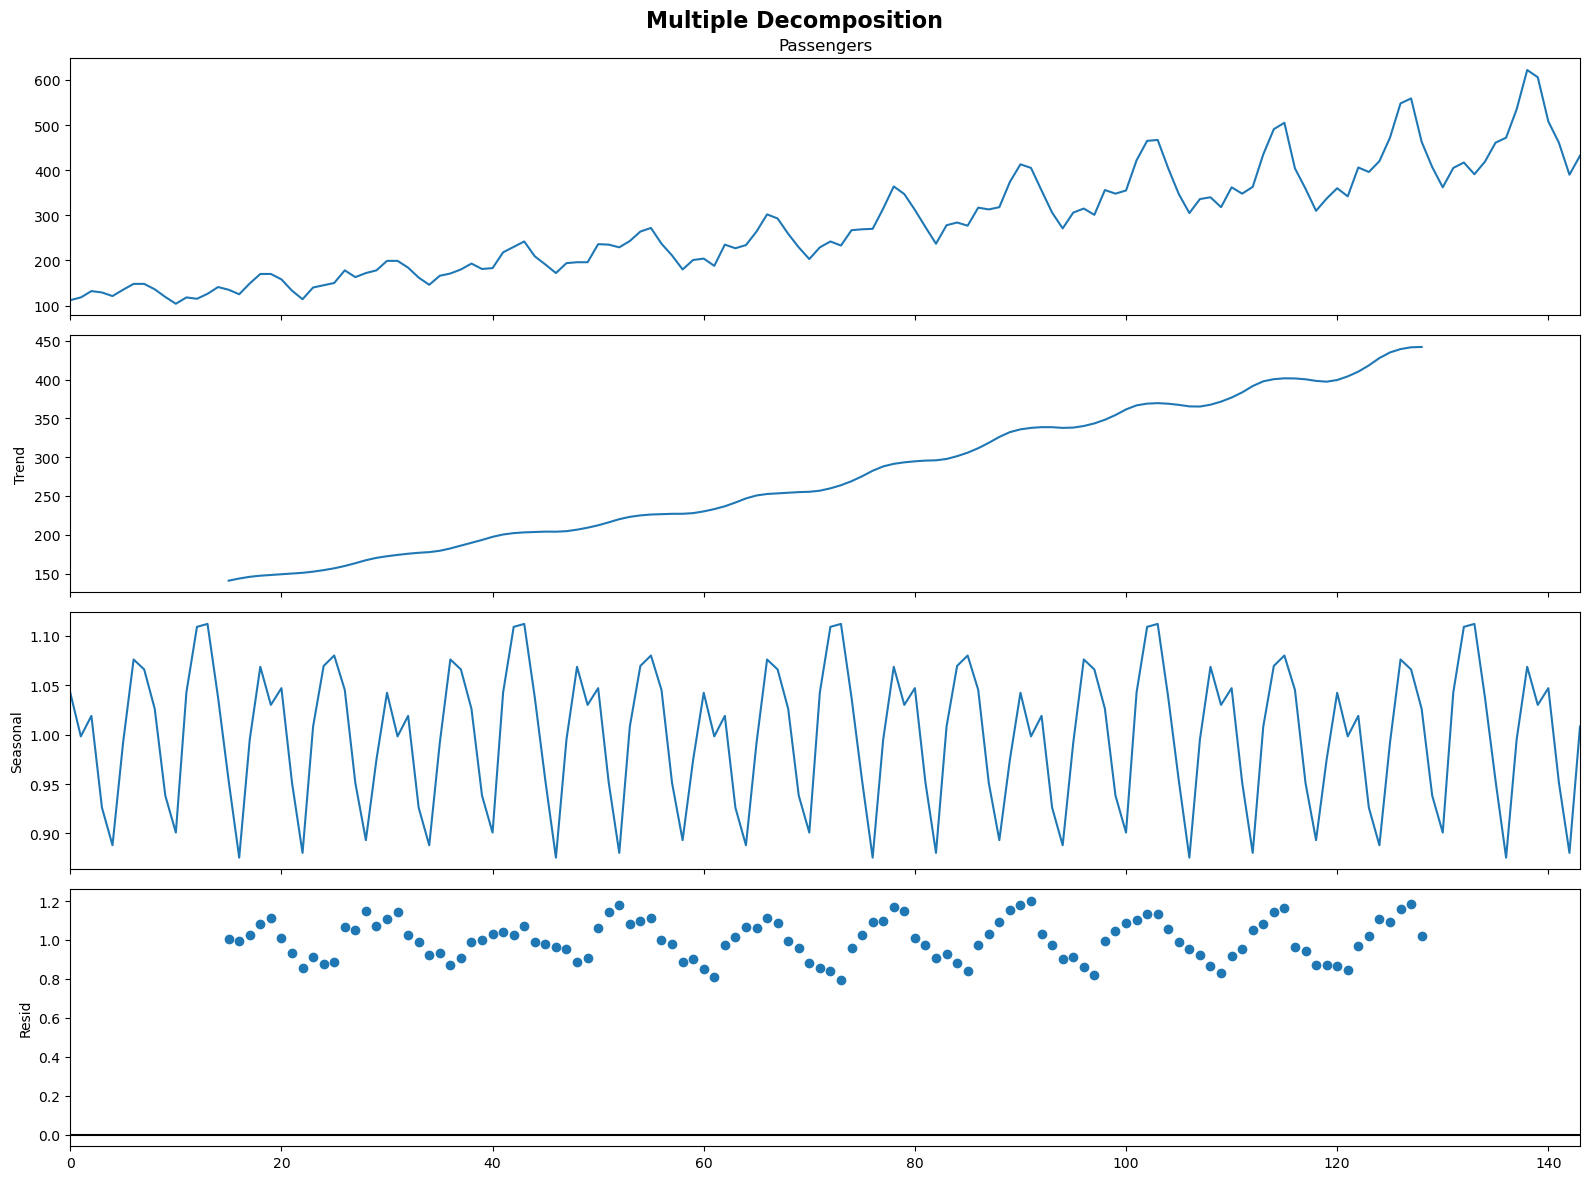

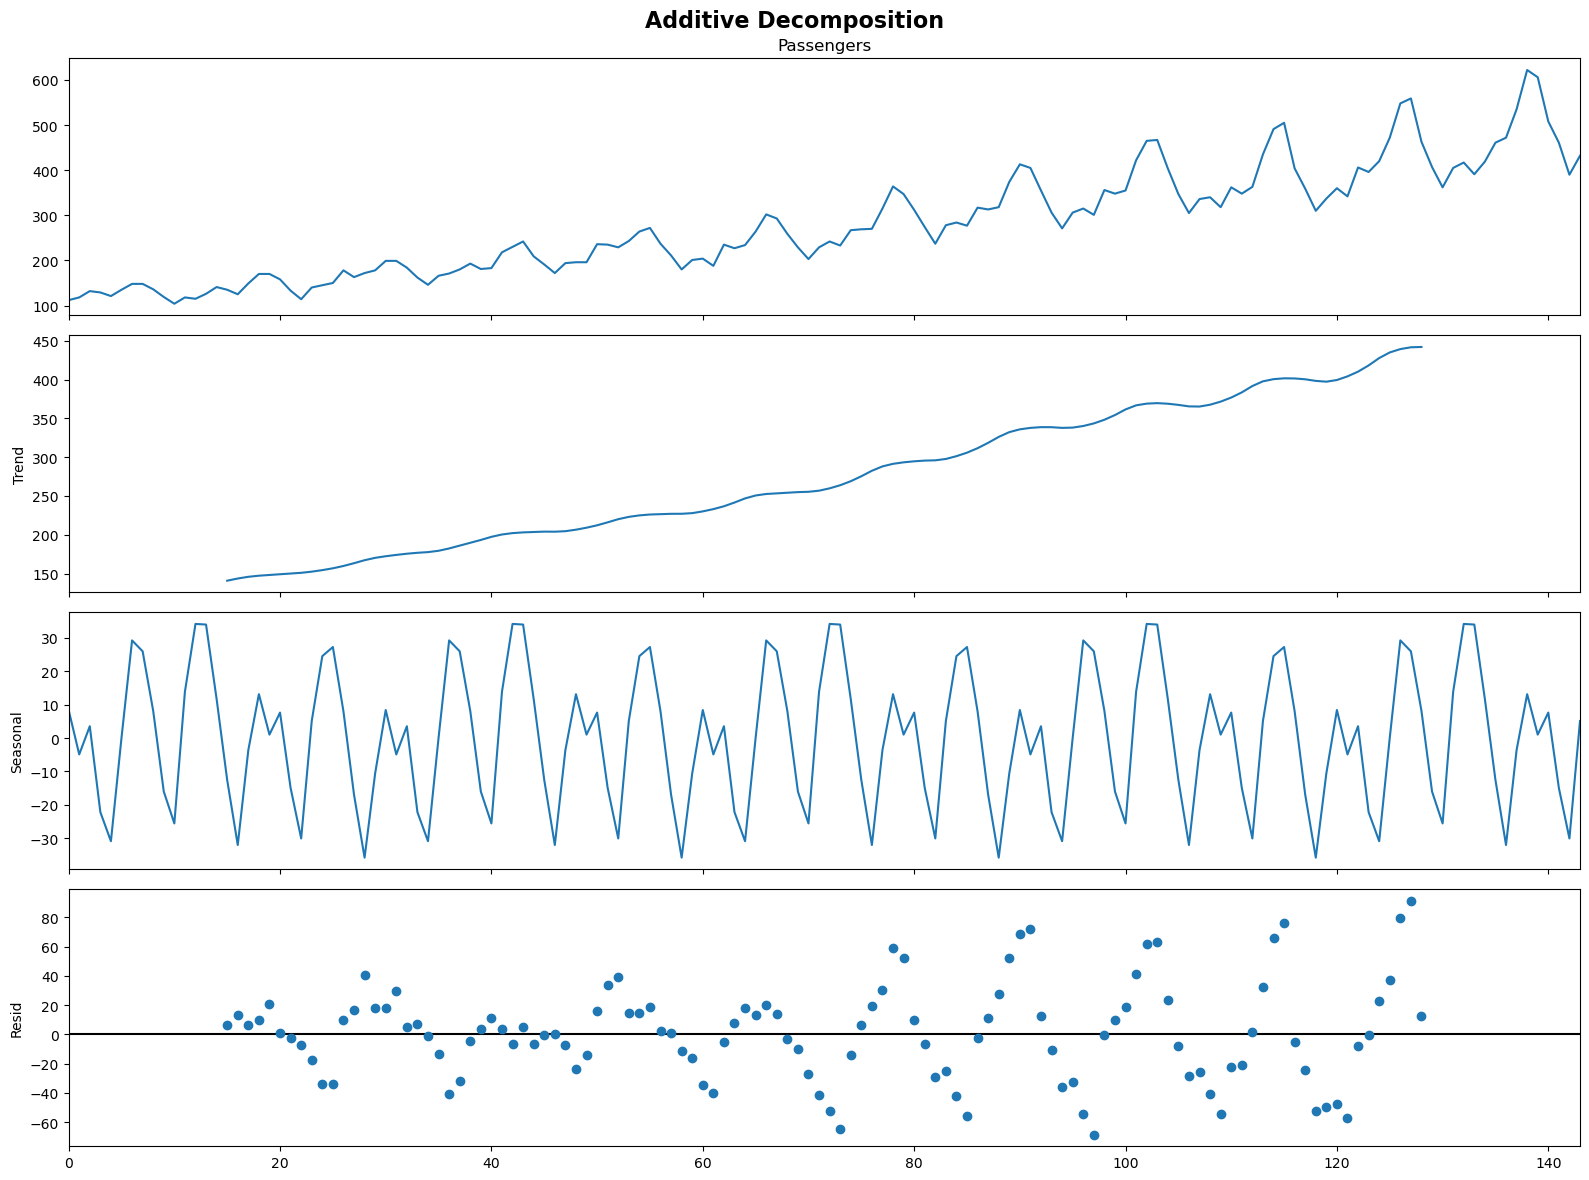

In [45]:
mult_decomp = seasonal_decompose(df["Passengers"], model = 'multiplicative', period = 30)
add_decomp = seasonal_decompose(df["Passengers"], model = 'additive', period = 30)

plt.rcParams.update({'figure.figsize': (16,12)})
mult_decomp.plot().suptitle('Multiple Decomposition', fontweight = 'bold', fontsize = 16)
plt.tight_layout()
add_decomp.plot().suptitle('Additive Decomposition', fontweight = 'bold', fontsize = 16)
plt.tight_layout()

plt.show()

In [46]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.head()

,Date,Passengers,Day,Month,Year
0,1949-01-01,112,1,1,1949
1,1949-02-01,118,1,2,1949
2,1949-03-01,132,1,3,1949
3,1949-04-01,129,1,4,1949
4,1949-05-01,121,1,5,1949


In [47]:
data = df[['Date', 'Day', 'Year', 'Month', 'Passengers']]
data = data.set_index('Date')
data.head()

,Day,Year,Month,Passengers
Date,,,,
1949-01-01,1,1949,1,112
1949-02-01,1,1949,2,118
1949-03-01,1,1949,3,132
1949-04-01,1,1949,4,129
1949-05-01,1,1949,5,121
